# The Multi-Agent Agentic Pattern — In Depth

## Table of Contents
1. [What Is It?](#what-is-it)
2. [Why Does It Matter?](#why-does-it-matter)
3. [How It Works — Architecture](#how-it-works--architecture)
4. [Comparison With Other Agentic Patterns](#comparison-with-other-agentic-patterns)
5. [Real-World Use Cases](#real-world-use-cases)
6. [Building It From Scratch (LangGraph)](#building-it-from-scratch-langgraph)
7. [Key Takeaways](#key-takeaways)

---

## What Is It?

**Multi-Agent** is an agentic AI design pattern where **multiple specialized LLM-powered agents** collaborate to solve a complex task — each agent has a **distinct role, expertise, and set of tools**, and they communicate through a shared workflow orchestrated by a **supervisor** (or peer-to-peer protocol).

Think of it like a **company with specialized departments**: a CEO (Supervisor) assigns work to the Research team, the Writing team, and the Quality Assurance team. Each department is an expert in its domain, and they pass work products between each other until the final deliverable is ready.

```mermaid
flowchart LR
    A["📥 User Request"] --> B["🧑‍💼 Supervisor"]
    B --> C["🔬 Researcher"]
    B --> D["✍️ Writer"]
    B --> E["🔍 Critic"]
    C --> B
    D --> B
    E --> B
    B --> F["🎯 Final Output"]
```

### The Core Idea

In all the patterns we've covered so far — prompt chaining, self-reflection, plan-and-execute — there is fundamentally **one agent** (sometimes with different "hats"). Multi-Agent breaks this paradigm by introducing **genuinely separate agents**, each with:

- **Its own system prompt** (defining its role and expertise)
- **Its own tools** (a researcher gets search; a coder gets code execution)
- **Its own memory/context** (scoped to what it needs to know)

These agents are coordinated by one of two mechanisms:

1. **Supervisor Pattern** — A central "boss" agent decides which specialist to call next
2. **Peer-to-Peer (Swarm) Pattern** — Agents hand off work to each other directly

> [!IMPORTANT]
> Multi-Agent is NOT just "calling the LLM multiple times." The key distinction is **role specialization with isolated contexts**. Each agent is an expert that sees only what it needs, uses only the tools it needs, and produces output scoped to its role. This isolation prevents context pollution and enables true division of labor.

### Academic Origins

The pattern draws from research on **LLM-based multi-agent collaboration** (Park et al., 2023 — "Generative Agents") and **AutoGen** (Wu et al., 2023), which demonstrated that teams of specialized agents consistently outperform single general-purpose agents on complex, multi-faceted tasks.

---

## Why Does It Matter?

### The Problem With Single-Agent Systems

Even sophisticated single agents (ReAct, Plan-and-Execute) hit a ceiling on truly complex tasks:

| Problem | Description |
|---------|-------------|
| **Context window overload** | One agent juggling research, writing, coding, and review fills up its context fast |
| **Jack of all trades** | A single system prompt can't make an LLM equally good at research AND writing AND coding |
| **Tool confusion** | Giving one agent 15+ tools leads to poor tool selection and hallucinated tool calls |
| **No checks and balances** | A single agent can't objectively critique its own work |
| **Monolithic failure** | If the agent gets confused mid-task, the entire workflow derails |

### What Multi-Agent Solves

| Benefit | How |
|---------|-----|
| **Deep specialization** | Each agent has a focused system prompt optimized for one role |
| **Scoped context** | Each agent sees only relevant information — no context pollution |
| **Right tools for the job** | Each agent gets only the tools it needs — better tool selection |
| **Built-in quality control** | Separate critic/reviewer agents provide objective evaluation |
| **Fault isolation** | If one agent struggles, others can compensate or the supervisor can reroute |
| **Scalability** | Add new specialist agents without modifying existing ones |

> [!TIP]
> Multi-Agent is the most powerful pattern when your task requires **multiple distinct skill sets** — e.g., a task that needs research + analysis + writing + review. If your task is a single skill (just writing, just coding), a simpler pattern like Self-Reflection is more appropriate.

---

## How It Works — Architecture

### The Two Main Topologies

#### Topology 1: Supervisor Pattern (Hierarchical)

A central supervisor agent acts as the "manager," deciding which specialist to invoke next:

```mermaid
flowchart TB
    subgraph "Supervisor Pattern"
        S["🧑‍💼 SUPERVISOR<br/>Routes tasks to specialists"]
        R["🔬 RESEARCHER<br/>Gathers information"]
        W["✍️ WRITER<br/>Creates content"]
        C["🔍 CRITIC<br/>Reviews quality"]
    end
    
    Input["📥 User Request"] --> S
    S -- "Need facts" --> R
    R -- "Research done" --> S
    S -- "Need content" --> W
    W -- "Draft ready" --> S
    S -- "Need review" --> C
    C -- "Feedback" --> S
    S --> Output["📤 Final Output"]
    
    style S fill:#4a9eff,color:#fff
    style R fill:#ff6b6b,color:#fff
    style W fill:#51cf66,color:#fff
    style C fill:#ffd43b,color:#333
```

**Pros**: Clear control flow, easy to debug, deterministic routing possible
**Cons**: Supervisor is a bottleneck, single point of failure

#### Topology 2: Peer-to-Peer (Swarm) Pattern

Agents hand off work to each other directly, with no central coordinator:

```mermaid
flowchart TB
    subgraph "Peer-to-Peer Pattern"
        R["🔬 RESEARCHER"] <--> W["✍️ WRITER"]
        W <--> C["🔍 CRITIC"]
        C <--> R
    end
    
    Input["📥 User Request"] --> R
    C --> Output["📤 Final Output"]
    
    style R fill:#ff6b6b,color:#fff
    style W fill:#51cf66,color:#fff
    style C fill:#ffd43b,color:#333
```

**Pros**: No bottleneck, agents can work in parallel, more resilient
**Cons**: Harder to debug, potential for infinite loops, complex coordination

> [!NOTE]
> In this tutorial, we'll implement the **Supervisor Pattern** as it's the most practical and widely-used approach. It's easier to reason about, debug, and control.

### The Core Components

#### 1. Supervisor (Orchestrator)
- Receives the original user request and all agent outputs
- Decides **which agent to call next** based on the current state
- Determines when the task is **complete**
- Has NO tools itself — its only job is routing and synthesis
- Uses a **strong model** for strategic decision-making

#### 2. Specialist Agents (Workers)
- Each has a **unique system prompt** defining its expertise
- Each has **domain-specific tools** (or no tools, for pure reasoning tasks)
- Receives a focused sub-task from the supervisor
- Returns its output to the supervisor for routing
- Can use **lighter models** since their reasoning is scoped

#### 3. Shared State (Communication Bus)
- All agents read from and write to a **shared message history**
- The supervisor uses this history to track progress and make routing decisions
- In LangGraph, this is typically a list of messages with agent identifiers

### State Management

```python
class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]     # Shared conversation history
    next_agent: str                              # Who the supervisor picks next
```

> [!NOTE]
> The `messages` list serves as the **shared communication bus**. Each agent appends its output as a message, and the supervisor reads the full history to decide the next step. This is simpler and more robust than complex inter-agent protocols.

### The Execution Flow — Step by Step

```mermaid
sequenceDiagram
    participant U as User
    participant S as Supervisor
    participant R as Researcher
    participant W as Writer
    participant C as Critic
    
    U->>S: "Write a blog post about quantum computing"
    S->>S: Analyze task — need research first
    S->>R: "Research quantum computing trends"
    R->>R: Uses web search tools
    R-->>S: Research findings
    
    S->>S: Research done — need writing next
    S->>W: "Write blog post using research"
    W->>W: Crafts the blog post
    W-->>S: Draft blog post
    
    S->>S: Draft done — need review
    S->>C: "Review this blog post for quality"
    C->>C: Evaluates quality
    C-->>S: "Good quality — minor suggestions"
    
    S->>S: Task complete
    S-->>U: Final polished blog post
```

---

## Comparison With Other Agentic Patterns

| Pattern | How It Works | When to Use |
|---------|-------------|-------------|
| **Prompt Chaining** | Sequential steps, fixed pipeline | Simple linear workflows |
| **Tool Use** | LLM calls external tools reactively | When external data/actions needed |
| **Self-Reflection** | Generate → Critique → Refine loop | Quality-critical single outputs |
| **Plan-and-Execute** | Plan → Execute → Replan loop | Complex multi-step goals |
| **Multi-Agent** | Multiple specialized agents collaborate via supervisor | Complex systems needing division of labor |

### Multi-Agent vs. Plan-and-Execute — The Key Distinction

| Dimension | Plan-and-Execute | Multi-Agent |
|-----------|-----------------|-------------|
| **Agent count** | Single executor (with tools) | Multiple specialized agents |
| **Specialization** | One agent does everything | Each agent is an expert in one area |
| **Context** | Shared across all steps | Scoped per agent role |
| **Tools** | All tools available to one agent | Tools distributed by specialization |
| **Quality assurance** | No built-in review | Dedicated critic/reviewer agent |
| **Scalability** | Add more plan steps | Add more specialist agents |
| **Complexity** | Moderate | High |
| **Best for** | Sequential multi-step tasks | Multi-skill collaborative tasks |

```mermaid
graph TB
    subgraph "Complexity Spectrum"
        A["Prompt Chaining<br/>⭐"] --> B["Tool Use<br/>⭐⭐"]
        B --> C["Self-Reflection<br/>⭐⭐⭐"]
        C --> D["Plan-and-Execute<br/>⭐⭐⭐⭐"]
        D --> E["Multi-Agent<br/>⭐⭐⭐⭐⭐"]
    end
    
    style E fill:#ff6b6b,color:#fff,stroke:#fff,stroke-width:2px
```

> [!TIP]
> **Hybrid approach**: In production, Multi-Agent systems often *contain* other patterns internally. For example, a Researcher agent might use **ReAct** (tool loops), a Writer agent might use **Self-Reflection** (draft-critique-refine), and the whole system is coordinated by a **Supervisor**. Patterns compose naturally.

---

## Real-World Use Cases

### 1. Content Production Pipeline
A Researcher gathers facts, a Writer creates the article, an Editor polishes grammar and style, and a Fact-Checker verifies claims. Each agent is specialized and the supervisor orchestrates the pipeline.

### 2. Software Development Team
A Product Manager agent interprets requirements, a Developer agent writes code, a Tester agent creates and runs tests, and a Code Reviewer agent evaluates quality. This mirrors real engineering team dynamics.

### 3. Customer Support Escalation
A Triage agent classifies the issue, a Technical Support agent handles technical problems, a Billing agent handles payment issues, and a Human Escalation agent routes to humans when needed.

### 4. Financial Analysis
A Data Collector agent gathers market data, a Quantitative Analyst agent runs models, a Risk Assessor agent evaluates risks, and a Report Writer agent creates the final investment report.

### 5. Legal Document Review
A Document Parser agent extracts key clauses, a Compliance Checker agent verifies regulatory requirements, a Risk Analyst agent identifies legal risks, and a Summary Writer agent produces the final review.

### 6. Medical Diagnosis Support
A Symptom Analyst agent processes patient input, a Differential Diagnosis agent generates possible conditions, a Literature Search agent finds relevant medical research, and a Report Generator agent creates a structured summary for the physician.

---

## Building It From Scratch (LangGraph)

Now let's build a complete, working Multi-Agent system using LangGraph. We'll create a **content production team** with:

1. A **Supervisor** that routes work between specialists
2. A **Researcher** agent with web search tools
3. A **Writer** agent that creates content from research
4. A **Critic** agent that reviews and provides feedback

The supervisor orchestrates the flow: Research → Write → Review → (Revise or Finish).

### Architecture of Our Implementation

```mermaid
flowchart TB
    START["▶ START"] --> supervisor["🧑‍💼 Supervisor Node<br/>Routes to the right specialist"]
    supervisor --> router{"🔀 Router Edge<br/>Which agent next?"}
    router -- "researcher" --> researcher["🔬 Researcher Node<br/>Searches the web for facts"]
    router -- "writer" --> writer["✍️ Writer Node<br/>Creates content from research"]
    router -- "critic" --> critic["🔍 Critic Node<br/>Reviews quality"]
    router -- "FINISH" --> END["⏹ END"]
    researcher --> supervisor
    writer --> supervisor
    critic --> supervisor
    
    style supervisor fill:#4a9eff,color:#fff
    style researcher fill:#ff6b6b,color:#fff
    style writer fill:#51cf66,color:#fff
    style critic fill:#ffd43b,color:#333
```


## Key Takeaways

> [!IMPORTANT]
> ### Summary of the Multi-Agent Pattern
> 
> 1. **What**: Multiple specialized LLM agents collaborate via a supervisor to tackle complex, multi-faceted tasks
> 2. **Why**: Single agents struggle with context overload, tool confusion, and lack of quality assurance on complex tasks
> 3. **How**: A Supervisor routes tasks to Specialist agents (Researcher, Writer, Critic, etc.), each with focused prompts and tools
> 4. **When**: Use when the task requires **multiple distinct skill sets** — research + writing + review, coding + testing + documentation, etc.
> 5. **Key advantage**: True division of labor with built-in quality control — each agent is an expert, and a dedicated critic ensures quality

### Design Principles

| Principle | Details |
|-----------|---------|
| **Role specialization** | Each agent has ONE job with a focused system prompt — don't create generalist agents |
| **Tool isolation** | Give each agent ONLY the tools it needs — reduces confusion and hallucinated tool calls |
| **Supervisor control** | A central supervisor prevents chaos, infinite loops, and ensures proper sequencing |
| **Scoped context** | Agents see the shared history but their prompts focus them on their role only |
| **Message tagging** | Tag each agent's output with its name so the supervisor can track who did what |
| **Safety valves** | Limit max iterations per agent and total workflow cycles to prevent runaway costs |

### Common Pitfalls to Avoid

| Pitfall | Solution |
|---------|----------|
| Too many agents (over-engineering) | Start with 2-3 agents; add more only when needed |
| Agents with overlapping roles | Define clear, non-overlapping responsibilities |
| Supervisor losing track | Include clear agent tags in messages; use structured output for routing |
| Infinite review loops | Limit critic rounds (max 2); accept "good enough" after second review |
| Context window explosion | Summarize long agent outputs; prune old messages if history grows too large |
| All agents using the same model | Tier your models: strong for supervisor, lighter for workers |

### When to Choose Multi-Agent Over Other Patterns

| Choose Multi-Agent When... | Choose Something Else When... |
|----------------------------|-------------------------------|
| The task needs 3+ distinct skill sets | The task is a single skill → use Self-Reflection |
| You need built-in quality assurance | You need a simple sequential pipeline → use Prompt Chaining |
| Different parts need different tools | You have one tool set → use ReAct |
| You want to scale by adding specialists | You need cost efficiency → use Plan-and-Execute |
| The task mirrors a real team workflow | The task is straightforward → use a simpler pattern |

---

> [!TIP]
> **Next steps**: Try building a **hierarchical multi-agent system** — a supervisor manages sub-supervisors, each of whom manages their own team of specialists. For example, a "Content Director" supervisor delegates to a "Research Team" sub-supervisor (managing multiple researchers) and a "Production Team" sub-supervisor (managing writers and editors). In LangGraph, you can implement this using **subgraphs** — each sub-team is a compiled subgraph that the top-level supervisor invokes as a single node.

## Complete Implementation Code

In [7]:
"""
Multi-Agent Agentic Pattern — LangGraph Implementation
=======================================================

This script implements the Multi-Agent (Supervisor) pattern where:
1. A Supervisor decides which specialist agent to call next
2. A Researcher agent gathers information using web search
3. A Writer agent creates polished content from research
4. A Critic agent reviews quality and provides feedback

Architecture:
    START → Supervisor → (Researcher | Writer | Critic) → Supervisor → ... → END

Key Concepts:
- Role specialization: each agent has a focused system prompt and tools
- Supervisor routing: central orchestrator decides the workflow
- Scoped context: agents see shared history but focus on their role
- Built-in quality control via dedicated critic agent
"""


'\nMulti-Agent Agentic Pattern — LangGraph Implementation\n=======================================================\n\nThis script implements the Multi-Agent (Supervisor) pattern where:\n1. A Supervisor decides which specialist agent to call next\n2. A Researcher agent gathers information using web search\n3. A Writer agent creates polished content from research\n4. A Critic agent reviews quality and provides feedback\n\nArchitecture:\n    START → Supervisor → (Researcher | Writer | Critic) → Supervisor → ... → END\n\nKey Concepts:\n- Role specialization: each agent has a focused system prompt and tools\n- Supervisor routing: central orchestrator decides the workflow\n- Scoped context: agents see shared history but focus on their role\n- Built-in quality control via dedicated critic agent\n'

In [16]:

# ==============================================================================
# Step 1: Imports and Setup
# ==============================================================================

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from typing import Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

# Strong model for the supervisor — needs strategic reasoning
supervisor_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)

# Worker models — can use lighter models for cost efficiency
worker_model = ChatGroq(model='llama-3.1-8b-instant', temperature=0.7)

In [17]:

# ==============================================================================
# Step 2: Define State and Supervisor Schema
# ==============================================================================

class SupervisorDecision(BaseModel):
    """The supervisor's routing decision."""
    next: str = Field(
        description="The next agent to call. Must be one of: "
                    "'researcher', 'writer', 'critic', or 'FINISH'"
    )
    reasoning: str = Field(
        description="Brief explanation of why this agent was chosen"
    )


class MultiAgentState(MessagesState):
    """
    State that flows through the multi-agent workflow.

    Fields:
        messages: Shared conversation history (inherited from MessagesState)
        next_agent: The supervisor's routing decision
    """
    next_agent: str



In [18]:

# ==============================================================================
# Step 3: Define the Supervisor Node
# ==============================================================================

supervisor_with_structure = supervisor_model.with_structured_output(SupervisorDecision)

TEAM_MEMBERS = ["researcher", "writer", "critic"]

def supervisor_node(state: MultiAgentState) -> dict:
    """
    Central supervisor that orchestrates the multi-agent workflow.

    Reads the full message history and decides:
    - Which specialist agent to call next
    - Or whether the task is complete (FINISH)
    """
    system_prompt = f"""You are a team supervisor managing a content production team.
Your team members are: {', '.join(TEAM_MEMBERS)}.

Each team member's specialty:
- **researcher**: Searches the web and gathers factual information. 
  Call this agent FIRST to gather raw material.
- **writer**: Takes research and creates well-structured, engaging content.
  Call this agent AFTER the researcher has gathered information.
- **critic**: Reviews written content for quality, accuracy, and completeness.
  Call this agent AFTER the writer has produced a draft.

Your workflow should generally follow: researcher → writer → critic → FINISH
However, if the critic finds significant issues, route back to the writer.

Rules:
- Call each agent at most 2 times to prevent infinite loops
- After the critic approves (or on the second review), select FINISH
- When selecting FINISH, the last substantial content in the conversation
  IS the final deliverable — do NOT regenerate it
- Consider the FULL conversation history when making decisions
"""

    messages = state["messages"]

    response = supervisor_with_structure.invoke(
        [SystemMessage(content=system_prompt)] + messages
    )

    print(f"\n{'='*60}")
    print(f"🧑‍💼 SUPERVISOR → {response.next}")
    print(f"   Reason: {response.reasoning}")
    print(f"{'='*60}")

    return {"next_agent": response.next}



In [19]:

# ==============================================================================
# Step 4: Define the Specialist Agent Nodes
# ==============================================================================

# ── Researcher Agent ──────────────────────────────────────
search_tool = TavilySearchResults(max_results=3)

researcher_agent = create_react_agent(
    worker_model,
    tools=[search_tool],
    prompt=(
        "You are an expert researcher. Your job is to gather comprehensive, "
        "factual information on the given topic using web search.\n\n"
        "Guidelines:\n"
        "- Search for multiple aspects of the topic\n"
        "- Include specific facts, statistics, and recent developments\n"
        "- Cite your sources when possible\n"
        "- Organize findings clearly with headers/bullet points\n"
        "- Focus on accuracy — do NOT fabricate information"
    ),
)

def researcher_node(state: MultiAgentState) -> dict:
    """Research agent: gathers factual information using web search."""
    result = researcher_agent.invoke(state)
    last_message = result["messages"][-1]

    print(f"\n{'─'*60}")
    print(f"🔬 RESEARCHER completed")
    print(f"   Output preview: {last_message.content[:200]}...")
    print(f"{'─'*60}")

    return {
        "messages": [
            AIMessage(
                content=f"[RESEARCHER REPORT]\n\n{last_message.content}",
                name="researcher"
            )
        ]
    }


# ── Writer Agent ──────────────────────────────────────────
writer_agent = create_react_agent(
    worker_model,
    tools=[],
    prompt=(
        "You are an expert content writer. Your job is to take research "
        "findings and create polished, engaging content.\n\n"
        "Guidelines:\n"
        "- Use the research provided in the conversation to write factual content\n"
        "- Create a clear structure: introduction, body sections, conclusion\n"
        "- Write in an engaging, accessible style for a general audience\n"
        "- Include specific examples and data points from the research\n"
        "- If you received feedback from the critic, address ALL their points\n"
        "- Aim for 500-800 words\n"
        "- Do NOT make up facts — use only what the researcher provided"
    ),
)

def writer_node(state: MultiAgentState) -> dict:
    """Writer agent: creates polished content from research findings."""
    result = writer_agent.invoke(state)
    last_message = result["messages"][-1]

    print(f"\n{'─'*60}")
    print(f"✍️  WRITER completed")
    print(f"   Output preview: {last_message.content[:200]}...")
    print(f"{'─'*60}")

    return {
        "messages": [
            AIMessage(
                content=f"[WRITER DRAFT]\n\n{last_message.content}",
                name="writer"
            )
        ]
    }


# ── Critic Agent ──────────────────────────────────────────
critic_agent = create_react_agent(
    worker_model,
    tools=[],
    prompt=(
        "You are an expert content critic and editor. Your job is to "
        "review content for quality, accuracy, and completeness.\n\n"
        "Evaluate against these criteria:\n"
        "1. **Accuracy**: Are facts correctly represented from the research?\n"
        "2. **Structure**: Is the content well-organized with clear flow?\n"
        "3. **Engagement**: Is the writing compelling and readable?\n"
        "4. **Completeness**: Does it cover all key aspects of the topic?\n"
        "5. **Clarity**: Is the language clear and jargon-free?\n\n"
        "Provide:\n"
        "- A quality verdict: APPROVE or NEEDS_REVISION\n"
        "- Specific strengths\n"
        "- Specific weaknesses (if any)\n"
        "- Concrete suggestions for improvement (if NEEDS_REVISION)"
    ),
)

def critic_node(state: MultiAgentState) -> dict:
    """Critic agent: reviews content quality and provides feedback."""
    result = critic_agent.invoke(state)
    last_message = result["messages"][-1]

    print(f"\n{'─'*60}")
    print(f"🔍 CRITIC completed")
    print(f"   Output preview: {last_message.content[:200]}...")
    print(f"{'─'*60}")

    return {
        "messages": [
            AIMessage(
                content=f"[CRITIC REVIEW]\n\n{last_message.content}",
                name="critic"
            )
        ]
    }



In [20]:

# ==============================================================================
# Step 5: Define the Router (Conditional Edge)
# ==============================================================================

def route_to_agent(state: MultiAgentState) -> Literal[
    "researcher", "writer", "critic", "__end__"
]:
    """
    Route to the next agent based on the supervisor's decision.
    Maps supervisor choices to graph node names.
    """
    next_agent = state.get("next_agent", "FINISH")

    if next_agent == "FINISH":
        return "__end__"

    return next_agent



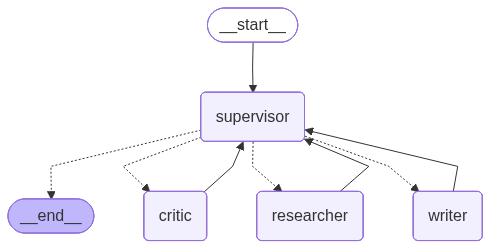

In [21]:

# ==============================================================================
# Step 6: Build the Graph
# ==============================================================================

# Create the graph
graph = StateGraph(MultiAgentState)

# Add nodes
graph.add_node("supervisor", supervisor_node)
graph.add_node("researcher", researcher_node)
graph.add_node("writer", writer_node)
graph.add_node("critic", critic_node)

# Add edges
graph.add_edge(START, "supervisor")             # Start → Supervisor

graph.add_conditional_edges(                    # Supervisor → (Agent or End)
    "supervisor",
    route_to_agent,
    {
        "researcher": "researcher",
        "writer": "writer",
        "critic": "critic",
        "__end__": END,
    }
)

# All agents report back to the supervisor
graph.add_edge("researcher", "supervisor")      # Researcher → Supervisor
graph.add_edge("writer", "supervisor")          # Writer → Supervisor
graph.add_edge("critic", "supervisor")          # Critic → Supervisor

# Compile the workflow
workflow = graph.compile()
workflow


In [ ]:

# ==============================================================================
# Step 7: Run It
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("🚀 MULTI-AGENT CONTENT TEAM — Starting")
    print("=" * 60)

    # Invoke the workflow with a content production request
    result = workflow.invoke({
        "messages": [
            HumanMessage(
                content="Write a comprehensive blog post about the current state "
                        "of quantum computing: recent breakthroughs, practical "
                        "applications, and what to expect in the next 5 years."
            )
        ]
    })

    # Print the final output (find the last writer message)
    print("\n" + "=" * 60)
    print("🎯 FINAL OUTPUT")
    print("=" * 60)

    for msg in reversed(result["messages"]):
        if hasattr(msg, "name") and msg.name == "writer":
            print(msg.content)
            break

    # Print collaboration summary
    print("\n" + "=" * 60)
    print("📊 COLLABORATION SUMMARY")
    print("=" * 60)

    agent_counts = {}
    for msg in result["messages"]:
        agent = getattr(msg, "name", msg.type)
        agent_counts[agent] = agent_counts.get(agent, 0) + 1

    print(f"  Total messages exchanged: {len(result['messages'])}")
    for agent, count in agent_counts.items():
        print(f"  {agent}: {count} message(s)")

    # Show agent conversation trail
    print("\n" + "=" * 60)
    print("🔍 AGENT CONVERSATION TRAIL")
    print("=" * 60)

    for i, msg in enumerate(result["messages"]):
        agent = getattr(msg, "name", msg.type)
        preview = msg.content[:150] if msg.content else "(no content)"
        print(f"\n  Message {i + 1} [{agent}]: {preview}")
        if len(msg.content or "") > 150:
            print("  ...")
